In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
 
print("Libraries loaded")

Libraries loaded


In [2]:
df_assam = pd.read_excel('../data/shg_data.xlsx')
 
print(f"Loaded: {df_assam.shape[0]:,} rows, {df_assam.shape[1]} columns")
print(f"State: {df_assam['State'].unique()}")
print(f"Status: {df_assam['Status (Active/Inactive)'].unique()}")
 

Loaded: 20,697 rows, 33 columns
State: <StringArray>
['ASSAM']
Length: 1, dtype: str
Status: <StringArray>
['Active']
Length: 1, dtype: str


In [3]:
def get_dist(series, replace_dash=True):
    """Get probability distribution from a column."""
    s = series.copy()
    if replace_dash:
        s = s.replace('-', 'unknown')
    s = s.str.replace('shg_', '', regex=False).str.strip()
    return s.value_counts(normalize=True).to_dict()
 
primary_dist    = get_dist(df_assam['Primary Livelihoods'])
secondary_dist  = get_dist(df_assam['Secondary Livelihoods'])
tertiary_dist   = get_dist(df_assam['Tertiary Livelihoods'])
category_dist   = get_dist(df_assam['SHG Category'], replace_dash=False)
category_dist   = {k.replace('-','unknown'): v for k, v in category_dist.items()}
savings_freq_dist = get_dist(df_assam['Savings Frequency'], replace_dash=False)
savings_freq_dist = {k.replace('-','Weekly'): v for k, v in savings_freq_dist.items()}
promoted_dist   = df_assam['Promoted By'].value_counts(normalize=True).to_dict()
 
members_mean = float(df_assam['Active Members'].mean())
members_std  = float(df_assam['Active Members'].std())
members_min  = int(df_assam['Active Members'].min())
members_max  = int(df_assam['Active Members'].max())
 
savings_mean = float(df_assam['Savings Amount'].mean())
savings_std  = float(df_assam['Savings Amount'].std())
 
print("Distributions extracted")
print(f"\nPrimary livelihoods: {list(primary_dist.keys())}")
print(f"Members range: {members_min} – {members_max}, mean: {members_mean:.1f}")
print(f"Savings range: 1 – 1000, mean: {savings_mean:.1f}")
 

Distributions extracted

Primary livelihoods: ['agriculture', 'unknown', 'manufacturing', 'livestock', 'fishery', 'horticulture', 'custom_hiring', 'live_aggregation', 'trading', 'services', 'ntfp']
Members range: 5 – 22, mean: 11.0
Savings range: 1 – 1000, mean: 36.5


In [4]:
states_config = {
    'UTTAR PRADESH': {
        'n': 4500, 'savings_mult': 1.1,
        'districts': ['Lucknow','Kanpur','Agra','Varanasi','Allahabad',
                      'Meerut','Bareilly','Gorakhpur','Jhansi','Mathura',
                      'Moradabad','Saharanpur','Muzaffarnagar','Aligarh','Firozabad'],
        'bias': {'agriculture':2.0,'livestock':1.5,'manufacturing':1.2,'unknown':0.8}
    },
    'BIHAR': {
        'n': 3500, 'savings_mult': 0.85,
        'districts': ['Patna','Gaya','Muzaffarpur','Bhagalpur','Darbhanga',
                      'Purnia','Nalanda','Saran','Siwan','Champaran',
                      'Munger','Nawada','Araria','Kishanganj','Jehanabad'],
        'bias': {'agriculture':2.2,'livestock':1.4,'fishery':1.3,'unknown':0.7}
    },
    'RAJASTHAN': {
        'n': 2800, 'savings_mult': 1.0,
        'districts': ['Jaipur','Jodhpur','Kota','Ajmer','Bikaner',
                      'Udaipur','Bharatpur','Alwar','Barmer','Nagaur',
                      'Sikar','Tonk','Dungarpur','Banswara','Churu'],
        'bias': {'livestock':2.0,'agriculture':1.5,'manufacturing':1.3,'trading':1.2,'unknown':0.8}
    },
    'MAHARASHTRA': {
        'n': 3200, 'savings_mult': 1.4,
        'districts': ['Pune','Nagpur','Nashik','Aurangabad','Solapur',
                      'Amravati','Kolhapur','Thane','Latur','Osmanabad',
                      'Nanded','Satara','Sangli','Raigad','Jalgaon'],
        'bias': {'manufacturing':2.0,'trading':1.8,'services':1.6,'agriculture':1.2,'unknown':0.6}
    },
    'GUJARAT': {
        'n': 2500, 'savings_mult': 1.5,
        'districts': ['Ahmedabad','Surat','Vadodara','Rajkot','Bhavnagar',
                      'Jamnagar','Junagadh','Gandhinagar','Anand','Mehsana',
                      'Kutch','Banaskantha','Sabarkantha','Patan','Valsad'],
        'bias': {'manufacturing':2.2,'trading':2.0,'services':1.5,'agriculture':1.0,'unknown':0.5}
    },
    'MADHYA PRADESH': {
        'n': 2800, 'savings_mult': 0.9,
        'districts': ['Bhopal','Indore','Jabalpur','Gwalior','Ujjain',
                      'Sagar','Dewas','Satna','Ratlam','Rewa',
                      'Singrauli','Burhanpur','Khandwa','Bhind','Chhindwara'],
        'bias': {'agriculture':2.0,'livestock':1.6,'manufacturing':1.1,'unknown':0.9}
    },
    'TAMIL NADU': {
        'n': 3000, 'savings_mult': 1.35,
        'districts': ['Chennai','Coimbatore','Madurai','Tiruchirappalli','Salem',
                      'Tirunelveli','Tiruppur','Erode','Vellore','Thoothukudi',
                      'Dindigul','Thanjavur','Ranipet','Sivaganga','Namakkal'],
        'bias': {'horticulture':1.8,'manufacturing':1.6,'services':1.8,'trading':1.5,'agriculture':1.2,'unknown':0.5}
    },
    'KARNATAKA': {
        'n': 2600, 'savings_mult': 1.3,
        'districts': ['Bengaluru','Mysuru','Hubballi','Mangaluru','Belagavi',
                      'Kalaburagi','Ballari','Vijayapura','Shivamogga','Tumakuru',
                      'Raichur','Bidar','Hassan','Dharwad','Chitradurga'],
        'bias': {'horticulture':1.7,'services':1.6,'manufacturing':1.4,'agriculture':1.3,'unknown':0.6}
    },
    'KERALA': {
        'n': 2200, 'savings_mult': 1.6,
        'districts': ['Thiruvananthapuram','Kochi','Kozhikode','Thrissur','Kollam',
                      'Kannur','Palakkad','Alappuzha','Malappuram','Kottayam',
                      'Idukki','Wayanad','Pathanamthitta','Kasaragod'],
        'bias': {'fishery':2.0,'horticulture':1.8,'services':1.9,'trading':1.6,'manufacturing':1.2,'unknown':0.4}
    },
    'ANDHRA PRADESH': {
        'n': 2400, 'savings_mult': 1.1,
        'districts': ['Visakhapatnam','Vijayawada','Guntur','Nellore','Kurnool',
                      'Tirupati','Kakinada','Rajahmundry','Kadapa','Anantapur',
                      'Eluru','Ongole','Srikakulam','Vizianagaram','Chittoor'],
        'bias': {'agriculture':1.8,'fishery':1.6,'horticulture':1.4,'manufacturing':1.1,'unknown':0.7}
    },
    'WEST BENGAL': {
        'n': 3000, 'savings_mult': 1.05,
        'districts': ['Kolkata','Murshidabad','Bardhaman','North 24 Parganas','South 24 Parganas',
                      'Hooghly','Medinipur','Howrah','Nadia','Malda',
                      'Bankura','Purulia','Birbhum','Jalpaiguri','Cooch Behar'],
        'bias': {'agriculture':1.8,'fishery':1.7,'manufacturing':1.3,'livestock':1.2,'unknown':0.7}
    },
    'ODISHA': {
        'n': 2200, 'savings_mult': 0.88,
        'districts': ['Bhubaneswar','Cuttack','Rourkela','Berhampur','Sambalpur',
                      'Puri','Balasore','Baripada','Bhadrak','Koraput',
                      'Ganjam','Keonjhar','Sundargarh','Rayagada','Kalahandi'],
        'bias': {'agriculture':2.0,'fishery':1.8,'livestock':1.4,'manufacturing':0.9,'unknown':0.8}
    },
    'MANIPUR': {
        'n': 800, 'savings_mult': 0.82,
        'districts': ['Imphal East','Imphal West','Thoubal','Bishnupur',
                      'Churachandpur','Senapati','Ukhrul','Chandel','Tamenglong'],
        'bias': {'agriculture':1.8,'fishery':1.6,'horticulture':1.4,'livestock':1.3,'unknown':0.8}
    },
    'MEGHALAYA': {
        'n': 700, 'savings_mult': 0.90,
        'districts': ['East Khasi Hills','West Khasi Hills','Ri Bhoi',
                      'East Jaintia Hills','West Jaintia Hills',
                      'East Garo Hills','West Garo Hills','South Garo Hills'],
        'bias': {'horticulture':2.0,'agriculture':1.6,'fishery':1.3,'livestock':1.2,'unknown':0.8}
    },
    'CHHATTISGARH': {
        'n': 1800, 'savings_mult': 0.87,
        'districts': ['Raipur','Bilaspur','Durg','Korba','Rajnandgaon',
                      'Raigarh','Jagdalpur','Ambikapur','Dhamtari','Kawardha',
                      'Mahasamund','Kondagaon','Kanker','Jashpur','Balod'],
        'bias': {'agriculture':2.0,'livestock':1.5,'manufacturing':1.0,'unknown':0.9}
    },
    'JHARKHAND': {
        'n': 1800, 'savings_mult': 0.85,
        'districts': ['Ranchi','Dhanbad','Jamshedpur','Bokaro','Hazaribagh',
                      'Deoghar','Giridih','Dumka','Pakur','Godda',
                      'Garhwa','Palamu','Lohardaga','Simdega','Khunti'],
        'bias': {'agriculture':1.9,'livestock':1.5,'manufacturing':1.1,'unknown':0.9}
    },
    'PUNJAB': {
        'n': 1500, 'savings_mult': 1.45,
        'districts': ['Ludhiana','Amritsar','Jalandhar','Patiala','Bathinda',
                      'Mohali','Hoshiarpur','Gurdaspur','Firozpur','Moga',
                      'Sangrur','Fatehgarh Sahib','Kapurthala','Faridkot'],
        'bias': {'agriculture':2.2,'manufacturing':1.5,'trading':1.4,'livestock':1.3,'unknown':0.5}
    },
}
 
total_synth = sum(v['n'] for v in states_config.values())
print(f"{len(states_config)} states configured")
print(f"   Total synthetic SHGs to generate: {total_synth:,}")

17 states configured
   Total synthetic SHGs to generate: 41,300


In [14]:
def apply_bias(base_dist, bias_dict):
    """Adjust livelihood probabilities by state bias."""
    adjusted = {k: v * bias_dict.get(k, 1.0) for k, v in base_dist.items()}
    total = sum(adjusted.values())
    return {k: v / total for k, v in adjusted.items()}
 
def sample_dist(dist, n):
    """Sample n values from a probability dict."""
    keys  = list(dist.keys())
    probs = np.array(list(dist.values()), dtype=float)
    probs = probs / probs.sum()
    return np.random.choice(keys, size=n, p=probs)
 
def fmt_livelihood(val):
    """Add shg_ prefix back, replace unknown with -"""
    return f"shg_{val}" if val != 'unknown' else '-'
 
shg_name_prefixes = ['Mahila','Janani','Shakti','Pragati','Udyog',
                     'Grameen','Swayam','Sahayog','Vikas','Jyoti',
                     'Samridhi','Navjyoti','Prerna','Asha','Sangam']
shg_name_suffixes = ['SHG','Samiti','Group','Sangathan','Mandal']
 
print("Helper functions ready")

Helper functions ready


In [17]:
all_frames   = []
code_offset  = int(df_assam['SHG Code'].max()) + 1
 
for state, cfg in states_config.items():
    n    = cfg['n']
    mult = cfg['savings_mult']
    dists= cfg['districts']
    bias = cfg['bias']
 
    # Adjusted livelihoods for this state
    p_primary   = apply_bias(primary_dist,   bias)
    p_secondary = apply_bias(secondary_dist, bias)
    p_tertiary  = apply_bias(tertiary_dist,  bias)
 
    # Geographic sampling
    s_district = np.random.choice(dists, size=n)
    dir_options = ['North','South','East','West','Central','Rural']
    s_block    = np.array([f"{d} {np.random.choice(dir_options)}" for d in s_district])
 
    # Numeric features
    s_members = np.clip(
        np.random.normal(members_mean, members_std, n).astype(int),
        members_min, members_max
    )
    s_savings = np.clip(
        np.random.normal(savings_mean * mult, savings_std, n).astype(int),
        1, 1000
    )
 
    # Categorical sampling
    s_primary   = sample_dist(p_primary,       n)
    s_secondary = sample_dist(p_secondary,     n)
    s_tertiary  = sample_dist(p_tertiary,      n)
    s_category  = sample_dist(category_dist,   n)
    s_sav_freq  = sample_dist(savings_freq_dist, n)
    s_promoted  = sample_dist(promoted_dist,   n)
    s_tenure    = np.random.choice([12, 24, 36], n)
 
    # SHG names
    s_names = [
        f"{np.random.choice(shg_name_prefixes)} "
        f"{d.split()[0]} "
        f"{np.random.choice(shg_name_suffixes)}"
        for d in s_district
    ]
 
    df_state = pd.DataFrame({
        'State':                          state,
        'District':                       s_district,
        'Block':                          s_block,
        'Gram Panchayat':                 [f"GP_{i}" for i in range(n)],
        'Village':                        [f"Village_{i}" for i in range(n)],
        'SHG Code':                       np.arange(code_offset, code_offset + n),
        'SHG Name':                       s_names,
        'SHG NIC Code':                   np.random.randint(100000, 999999, n).astype(str),
        'SHG Category':                   s_category,
        'Date of Formation':              pd.NaT,
        'Active Members':                 s_members,
        'Primary Parent CBO (VO)':        [f"VO_{state[:3]}_{i}" for i in range(n)],
        'Secondary Parent CBO (CLF)':     [f"CLF_{state[:3]}_{i}" for i in range(n)],
        'Promoted By':                    s_promoted,
        'Promoters Name':                 np.nan,
        'Co-option Status':               'No',
        'Co-option/Revival Date':         np.nan,
        'SHG Type':                       'Woman(Regular)',
        'Special SHG Type':               'none',
        'Meeting Frequency':              'Weekly',
        'Savings Frequency':              s_sav_freq,
        'Savings Amount':                 s_savings,
        'Tenure of Office Bearers (Months)': s_tenure,
        'Primary Livelihoods':            [fmt_livelihood(v) for v in s_primary],
        'Secondary Livelihoods':          [fmt_livelihood(v) for v in s_secondary],
        'Tertiary Livelihoods':           [fmt_livelihood(v) for v in s_tertiary],
        'Status (Active/Inactive)':       'Active',
        '1st Account Number':             np.random.randint(10**10, 10**12, n, dtype=np.int64),
        '1st Account Type':               'Savings (Default)',
        '1st IFSC':                       [f"SBIN{np.random.randint(1000000,9999999)}" for _ in range(n)],
        '1st Branch Name':                s_district,
        '1st Bank Name':                  np.random.choice(
                                              ['STATE BANK OF INDIA','PUNJAB NATIONAL BANK',
                                               'CANARA BANK','BANK OF BARODA','UNION BANK'], n),
        '1st Account Opening Date':       pd.NaT,
        'is_synthetic':                   True,
    })
 
    code_offset += n
    all_frames.append(df_state)
    print(f"  {state:<25} → {n:,} rows")
 
df_synthetic = pd.concat(all_frames, ignore_index=True)
print(f"\nTotal synthetic rows: {len(df_synthetic):,}")

  UTTAR PRADESH             → 4,500 rows
  BIHAR                     → 3,500 rows
  RAJASTHAN                 → 2,800 rows
  MAHARASHTRA               → 3,200 rows
  GUJARAT                   → 2,500 rows
  MADHYA PRADESH            → 2,800 rows
  TAMIL NADU                → 3,000 rows
  KARNATAKA                 → 2,600 rows
  KERALA                    → 2,200 rows
  ANDHRA PRADESH            → 2,400 rows
  WEST BENGAL               → 3,000 rows
  ODISHA                    → 2,200 rows
  MANIPUR                   → 800 rows
  MEGHALAYA                 → 700 rows
  CHHATTISGARH              → 1,800 rows
  JHARKHAND                 → 1,800 rows
  PUNJAB                    → 1,500 rows

Total synthetic rows: 41,300


In [18]:
df_assam['is_synthetic'] = False
 
df_combined = pd.concat([df_assam, df_synthetic], ignore_index=True)
 
print(f"✅ Combined dataset: {len(df_combined):,} rows")
print(f"\nState distribution:")
print(df_combined['State'].value_counts().to_string())
print(f"\nReal:      {df_assam.shape[0]:,}")
print(f"Synthetic: {len(df_synthetic):,}")
print(f"Total:     {len(df_combined):,}")

✅ Combined dataset: 61,997 rows

State distribution:
State
ASSAM             20697
UTTAR PRADESH      4500
BIHAR              3500
MAHARASHTRA        3200
TAMIL NADU         3000
WEST BENGAL        3000
RAJASTHAN          2800
MADHYA PRADESH     2800
KARNATAKA          2600
GUJARAT            2500
ANDHRA PRADESH     2400
KERALA             2200
ODISHA             2200
CHHATTISGARH       1800
JHARKHAND          1800
PUNJAB             1500
MANIPUR             800
MEGHALAYA           700

Real:      20,697
Synthetic: 41,300
Total:     61,997


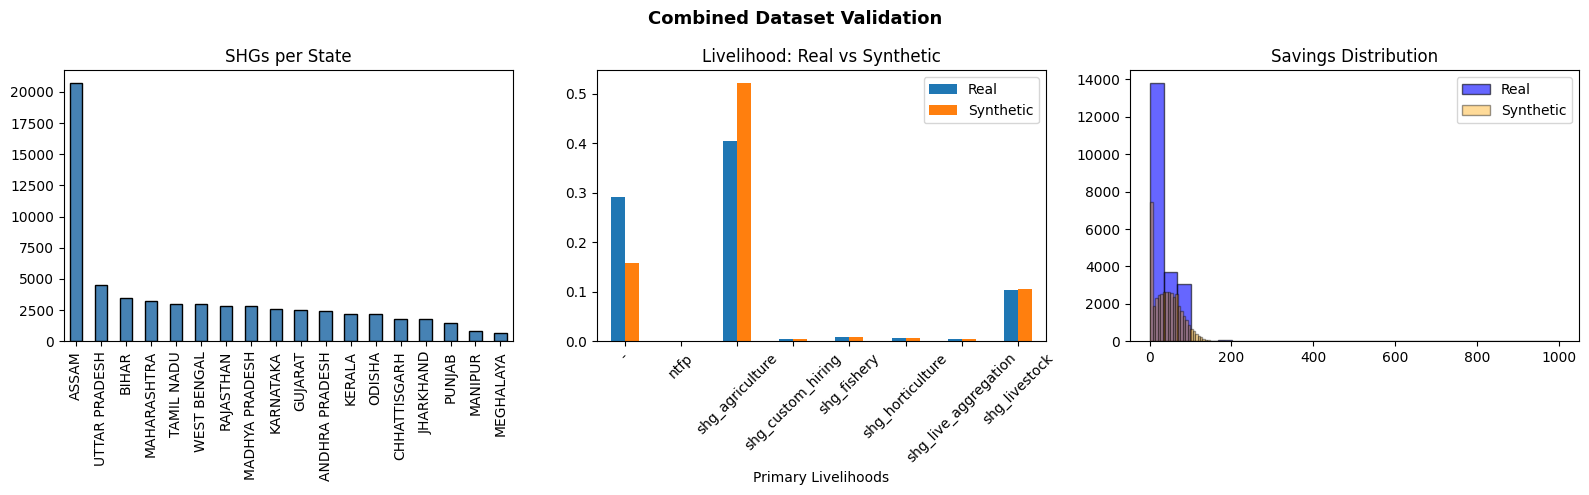

Plot saved → data/combined_dataset_overview.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Combined Dataset Validation', fontsize=13, fontweight='bold')
 
# State counts
df_combined['State'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('SHGs per State')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=90)
 
# Livelihood comparison
real_liv  = df_combined[~df_combined['is_synthetic']]['Primary Livelihoods'].value_counts(normalize=True)
synth_liv = df_combined[df_combined['is_synthetic']]['Primary Livelihoods'].value_counts(normalize=True)
pd.DataFrame({'Real': real_liv, 'Synthetic': synth_liv}).fillna(0).head(8).plot(
    kind='bar', ax=axes[1])
axes[1].set_title('Livelihood: Real vs Synthetic')
axes[1].tick_params(axis='x', rotation=45)
 
# Savings distribution
axes[2].hist(df_assam['Savings Amount'], bins=30,
             alpha=0.6, label='Real', color='blue', edgecolor='black')
axes[2].hist(df_synthetic['Savings Amount'], bins=30,
             alpha=0.4, label='Synthetic', color='orange', edgecolor='black')
axes[2].set_title('Savings Distribution')
axes[2].legend()
 
plt.tight_layout()
plt.savefig('../data/combined_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → data/combined_dataset_overview.png")

In [21]:
output_path = '../data/shg_combined.csv'
df_combined.to_csv(output_path, index=False)
 
print(f" Saved → {output_path}")
print(f"   Rows:   {len(df_combined):,}")
print(f"   States: {df_combined['State'].nunique()}")


 Saved → ../data/shg_combined.csv
   Rows:   61,997
   States: 18
